Dataset has 2033 datapoints, and each datapoint has 10 results each.

In [54]:
import itertools

from tqdm.notebook import tqdm
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


total_datapoints = 2033
max_judge_queries = total_datapoints*20
failure_probability_delta = 0.1

def judge_query(p_r_pair):
    """
    Queries a prompt response pair to the judge LLM
    :param p_a_pair:
    :return:
    """

def data_reader(filename):
    """
    Reads the data from the json file into a pandas dataset
    :return:
    """
    return pd.read_json(filename, lines=True)

class UCB:
    def __init__(self, n_pairs, df):
        self.n_pairs = n_pairs
        self.reset_algo()
        self.dataframe = df

    def reset_algo(self):
        self.responses = [np.empty(0) for _ in range(self.n_pairs)]          # Number of times each arm was pulled

    def select_pair(self, selection_method = "ucb"):
        # If any pair hasn't been tried 4log(1/\delta), try it first

        selection_criteria_values = [0.0] * self.n_pairs
        if selection_method == "ucb":
            for pair in range(self.n_pairs):
                if self.responses[pair].shape[0] < math.log(1/failure_probability_delta,2)*4:
                    return pair
            for pair in range(self.n_pairs):
                selection_criteria_values[pair] = self.get_ucb_value(pair)
        if selection_method == "ground_variance":
            for pair in range(self.n_pairs):
                selection_criteria_values[pair] = self.get_ground_truth_variance(pair)  # Ground truth variance here
        return selection_criteria_values.index(max(selection_criteria_values))

    def get_pair_information(self, pair, information):
        if information == "predicted_score":
            return self.dataframe.iloc[pair*10+((self.responses[pair].shape[0])%10)]["predicted_score"]
        else:
            return self.dataframe.iloc[pair*10][information]

    def get_ground_truth_variance(self, pair):
        ground_truth_var = np.square(np.array(df.iloc[pair*10:(pair+1)*10]["predicted_score"]).mean()).sum()/9
        return ground_truth_var

    def get_ucb_value(self, pair_number):
        return self.get_sample_covariance(self.responses[pair_number])/(1-(2*math.sqrt(math.log(1/failure_probability_delta,2)/self.responses[pair_number].shape[0])))

    def get_sample_covariance(self, selected_pair_responses):
        return np.square(selected_pair_responses-selected_pair_responses.mean()).sum()/(selected_pair_responses.shape[0]-1)

    def get_all_sample_covariance(self):
        to_return = []
        for pair in range(self.n_pairs):
            to_return.append(self.get_sample_covariance(self.responses[pair]))
        to_return = np.array(to_return)
        return to_return

    def update(self, chosen_pair):
        new_value = self.get_pair_information(chosen_pair, information="predicted_score")
        clipped_new_value = max(min(new_value, 5), 0)
        self.responses[chosen_pair] = np.append(self.responses[chosen_pair], clipped_new_value)

    def get_estimated_rating(self, pair_number):
        return self.responses[pair_number].mean()

    def get_total_error(self, type = "squared_error"):
        total_error = 0
        for pair in range(self.n_pairs):
            total_error += (self.get_pair_information(pair, "human_score") - self.responses[pair].mean())**2
        return total_error

    def run_algo_uniform(self, number_of_queries = max_judge_queries, error_type = "squared_error"):
        self.reset_algo()
        total_errors = []
        for iteration in tqdm(range(int(number_of_queries))):
            pair_number = iteration%self.n_pairs
            algorithm.update(pair_number)
            if iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
        return total_errors

    def run_algo_UCB(self, number_of_queries = max_judge_queries, error_type = "squared_error"):
        self.reset_algo()
        total_errors = []
        for iteration in tqdm(range(int(number_of_queries))):
            most_uncertain_pair = algorithm.select_pair(selection_method = "ucb")
            if iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
            algorithm.update(most_uncertain_pair)
        return total_errors

    def run_algo_ground_truth_var(self, number_of_queries = max_judge_queries, error_type = "squared_error"):
        self.reset_algo()
        total_errors = []
        for iteration in tqdm(range(int(number_of_queries))):
            most_uncertain_pair = algorithm.select_pair(selection_method = "ground_variance")
            if iteration % 100 == 0:
                total_errors.append(self.get_total_error(error_type))
            algorithm.update(most_uncertain_pair)
        return total_errors

In [56]:
df = data_reader("helpsteer2.jsonl")
algorithm = UCB(total_datapoints, df)
df.head(20)

,prompt,response,human_score,rationale,predicted_score
0,c#,"C# is a high-level, object-oriented programmin...",3,The response accurately describes the key feat...,2
1,c#,"C# is a high-level, object-oriented programmin...",3,The response accurately describes the key feat...,2
2,c#,"C# is a high-level, object-oriented programmin...",3,The response accurately describes the key feat...,3
3,c#,"C# is a high-level, object-oriented programmin...",3,The response accurately describes the main cha...,2
4,c#,"C# is a high-level, object-oriented programmin...",3,The response accurately describes the key feat...,2
5,c#,"C# is a high-level, object-oriented programmin...",3,The response accurately describes the key feat...,2
6,c#,"C# is a high-level, object-oriented programmin...",3,The response accurately describes the key feat...,3
7,c#,"C# is a high-level, object-oriented programmin...",3,"C# is a high-level, object-oriented programmin...",4
8,c#,"C# is a high-level, object-oriented programmin...",3,"C# is a high-level, object-oriented programmin...",3
9,c#,"C# is a high-level, object-oriented programmin...",3,The response accurately describes the key feat...,2


In [57]:
uniform_errors = algorithm.run_algo_uniform()
UCB_errors = algorithm.run_algo_UCB()
ground_truth_variance_errors = algorithm.run_algo_ground_truth_var()

  0%|          | 0/40660 [00:00<?, ?it/s]

C:\Users\anike\AppData\Local\Temp\ipykernel_12472\1195976744.py:87: RuntimeWarning: Mean of empty slice.
  total_error += (self.get_pair_information(pair, "human_score") - self.responses[pair].mean())**2
S:\programming\anaconda\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | 0/40660 [00:00<?, ?it/s]

  0%|          | 0/40660 [00:00<?, ?it/s]

KeyboardInterrupt: 

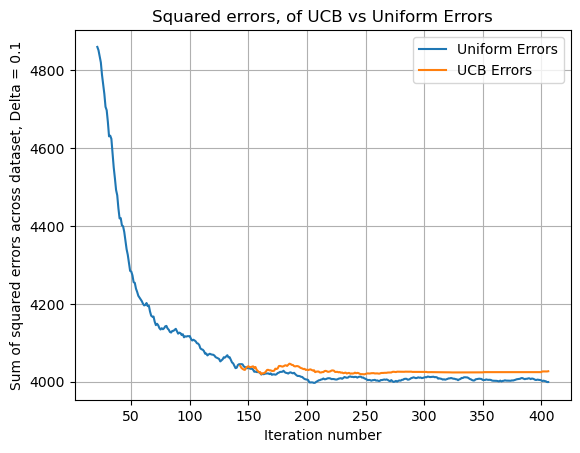

In [53]:
plt.plot(uniform_errors, label='Uniform Errors')
plt.plot(UCB_errors, label='UCB Errors')
plt.plot(ground_truth_variance_errors, label='Ground Truth Variance Errors')
plt.title('Squared errors, of UCB vs Uniform vs Ground Truth Variance')
plt.xlabel('Iteration number')
plt.ylabel('Sum of squared errors across dataset, Delta = 0.1')
plt.legend()
plt.grid(True)
plt.show()

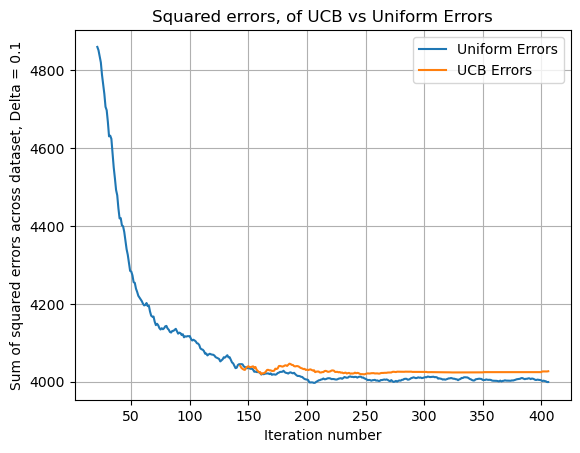

In [53]:
plt.plot(uniform_errors, label='Uniform Errors')
plt.plot(UCB_errors, label='UCB Errors')
plt.title('Squared errors, of UCB vs Uniform Errors')
plt.xlabel('Iteration number')
plt.ylabel('Sum of squared errors across dataset, Delta = 0.1')
plt.legend()
plt.grid(True)
plt.show()

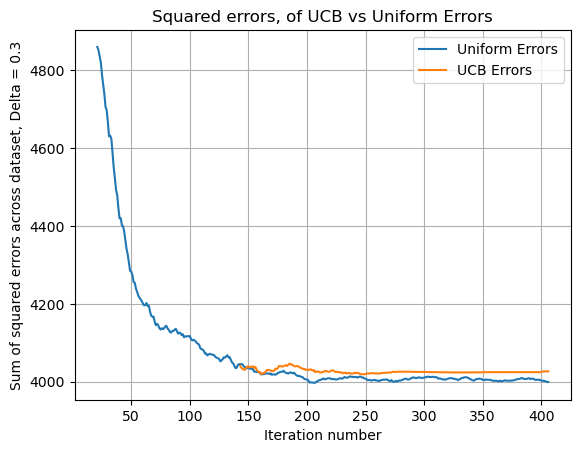

In [39]:
plt.plot(uniform_errors, label='Uniform Errors')
plt.plot(UCB_errors, label='UCB Errors')
plt.title('Squared errors, of UCB vs Uniform Errors')
plt.xlabel('Iteration number')
plt.ylabel('Sum of squared errors across dataset, Delta = 0.3')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
for iteration in tqdm(range(int(max_judge_queries))):
    most_uncertain_pair = algorithm.select_pair()
    if iteration > total_datapoints*14and iteration % 1000 == 0:
        print(most_uncertain_pair)
    algorithm.update(most_uncertain_pair)

<>:5: SyntaxWarning: invalid decimal literal
<>:5: SyntaxWarning: invalid decimal literal
C:\Users\anike\AppData\Local\Temp\ipykernel_12744\121720781.py:5: SyntaxWarning: invalid decimal literal
  if iteration > total_datapoints*14and iteration % 1000 == 0:


  0%|          | 0/40660 [00:00<?, ?it/s]

803
491
884
240
1542
809
114
1812
353
714
1502
639


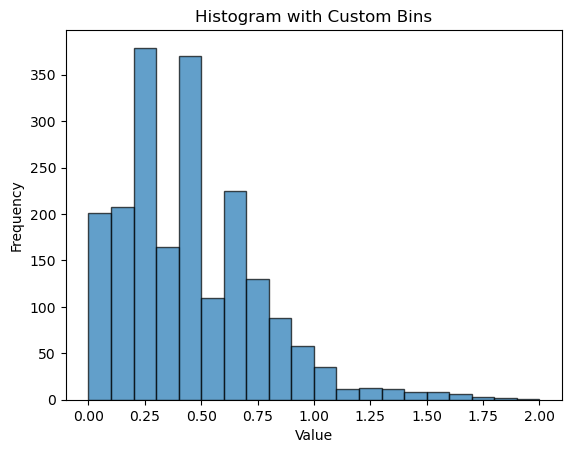

In [39]:

# Sample data
data = algorithm.get_all_sample_covariance()

# Specify custom bins
bins = [0, 0.1, 0.2, 0.3 ,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3 ,1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

# Create histogram
plt.hist(data, bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram with Custom Bins')
plt.show()
